In [1]:
from google.colab import files
import pandas as pd
uploaded = files.upload()

df = pd.read_csv('AllProductReviews.csv')
print(df.head())

Saving AllProductReviews.csv to AllProductReviews.csv
                                        ReviewTitle  \
0             Honest review of an edm music lover\n   
1             Unreliable earphones with high cost\n   
2                        Really good and durable.\n   
3                 stopped working in just 14 days\n   
4  Just Awesome Wireless Headphone under 1000...😉\n   

                                          ReviewBody  ReviewStar  \
0  No doubt it has a great bass and to a great ex...           3   
1  This  earphones are unreliable, i bought it be...           1   
2  i bought itfor 999,I purchased it second time,...           4   
3  Its sound quality is adorable. overall it was ...           1   
4  Its Awesome... Good sound quality & 8-9 hrs ba...           5   

            Product  
0  boAt Rockerz 255  
1  boAt Rockerz 255  
2  boAt Rockerz 255  
3  boAt Rockerz 255  
4  boAt Rockerz 255  


In [2]:
print("Shape:", df.shape)
print()
print(df.head(10))

Shape: (14337, 4)

                                         ReviewTitle  \
0              Honest review of an edm music lover\n   
1              Unreliable earphones with high cost\n   
2                         Really good and durable.\n   
3                  stopped working in just 14 days\n   
4   Just Awesome Wireless Headphone under 1000...😉\n   
5                        Charging port not working\n   
6                     Loved the color and sound !!\n   
7                      Great sound with worst mic.\n   
8  Battery life is good enough to keep going all ...   
9                           Very very bad Durabity\n   

                                          ReviewBody  ReviewStar  \
0  No doubt it has a great bass and to a great ex...           3   
1  This  earphones are unreliable, i bought it be...           1   
2  i bought itfor 999,I purchased it second time,...           4   
3  Its sound quality is adorable. overall it was ...           1   
4  Its Awesome... Good s

In [3]:
#to keep columns we need
df = df[['ReviewBody', 'ReviewStar']].dropna()

#to convert star ratings to sentiment labels
def get_label(star):
    if star <= 2:
        return 0  # negative
    elif star == 3:
        return 1  # neutral
    else:
        return 2  # positive

df['label'] = df['ReviewStar'].apply(get_label)

print(df['label'].value_counts())

label
2    9402
0    3432
1    1503
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X = df['ReviewBody']
y = df['label']

# First split: 80% train set, 20% tempory set
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, #helps ensure same split everytime code is run
    stratify=y #keeps the ratio of negative/neutral/positive the same in both splits
)

#split temporary set evenly into validation and test sets
# Second split: split temp evenly into val and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, # 50% of temp becomes test, 50% becomes val
    random_state=42,
    stratify=y_temp
)

print("X_train size:", len(X_train))
print("X_test size:", len(X_test))
print("X_val size:", len(X_val))

X_train size: 11469
X_test size: 1434
X_val size: 1434


In [5]:
#TRAINING THE MODEL
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

#1. convert text to numbers
vectorizer = TfidfVectorizer(max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

#2 train the model
model = LinearSVC()
model.fit(X_train_vec, y_train)

LinearSVC()

In [6]:
#RESULTS
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test_vec)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print()
print(classification_report(
    y_test, y_pred,
    target_names=['negative', 'neutral', 'positive']
))

Accuracy: 0.8

              precision    recall  f1-score   support

    negative       0.74      0.76      0.75       343
     neutral       0.19      0.07      0.11       151
    positive       0.86      0.93      0.89       940

    accuracy                           0.80      1434
   macro avg       0.59      0.59      0.58      1434
weighted avg       0.76      0.80      0.77      1434



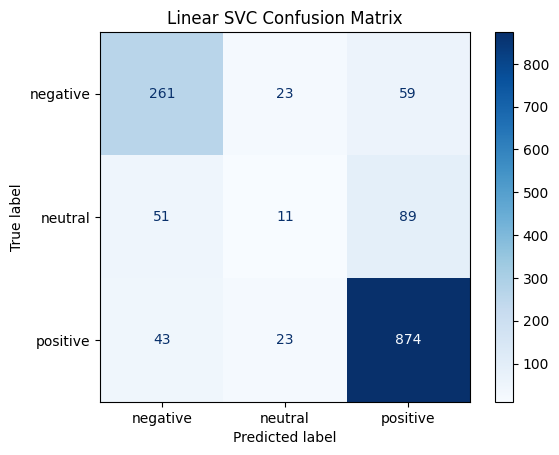

In [7]:
#confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['negative', 'neutral', 'positive'],
    cmap='Blues'
)
plt.title('Linear SVC Confusion Matrix')
plt.show()